In [61]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from matplotlib.colors import LogNorm

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [62]:
# A)
x1, x2 = sp.symbols('x1 x2', real=True)

EL_sym = x1**2 / sp.Rational(3,2) + x2**2 / sp.Rational(3,2) + \
         3 * sp.sin((x1 + x2) / sp.sqrt(2))**2

grad_EL_sym = sp.Matrix([sp.diff(EL_sym, x1), sp.diff(EL_sym, x2)])
hess_EL_sym = sp.hessian(EL_sym, [x1, x2])

grad_EL_sym, hess_EL_sym

(Matrix([
 [4*x1/3 + 3*sqrt(2)*sin(sqrt(2)*(x1 + x2)/2)*cos(sqrt(2)*(x1 + x2)/2)],
 [4*x2/3 + 3*sqrt(2)*sin(sqrt(2)*(x1 + x2)/2)*cos(sqrt(2)*(x1 + x2)/2)]]),
 Matrix([
 [-3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2 + 4/3,       -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2],
 [      -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2, -3*sin(sqrt(2)*(x1 + x2)/2)**2 + 3*cos(sqrt(2)*(x1 + x2)/2)**2 + 4/3]]))

In [63]:
ER_sym = (1 - x1)**2 + 100*(x2 - x1**2)**2

grad_ER_sym = sp.Matrix([sp.diff(ER_sym, x1), sp.diff(ER_sym, x2)])
hess_ER_sym = sp.hessian(ER_sym, [x1, x2])

grad_ER_sym, hess_ER_sym

(Matrix([
 [-400*x1*(-x1**2 + x2) + 2*x1 - 2],
 [             -200*x1**2 + 200*x2]]),
 Matrix([
 [1200*x1**2 - 400*x2 + 2, -400*x1],
 [                -400*x1,     200]]))

In [64]:
args = [x1, x2]

EL_fn  = sp.lambdify(args, EL_sym,       'numpy')
gEL_fn = sp.lambdify(args, grad_EL_sym,  'numpy')
HEL_fn = sp.lambdify(args, hess_EL_sym,  'numpy')

ER_fn  = sp.lambdify(args, ER_sym,       'numpy')
gER_fn = sp.lambdify(args, grad_ER_sym,  'numpy')
HER_fn = sp.lambdify(args, hess_ER_sym,  'numpy')

def grad_EL(x): return np.array(gEL_fn(x[0], x[1]), dtype=float).flatten()
def hess_EL(x): return np.array(HEL_fn(x[0], x[1]), dtype=float)

def grad_ER(x): return np.array(gER_fn(x[0], x[1]), dtype=float).flatten()
def hess_ER(x): return np.array(HER_fn(x[0], x[1]), dtype=float)

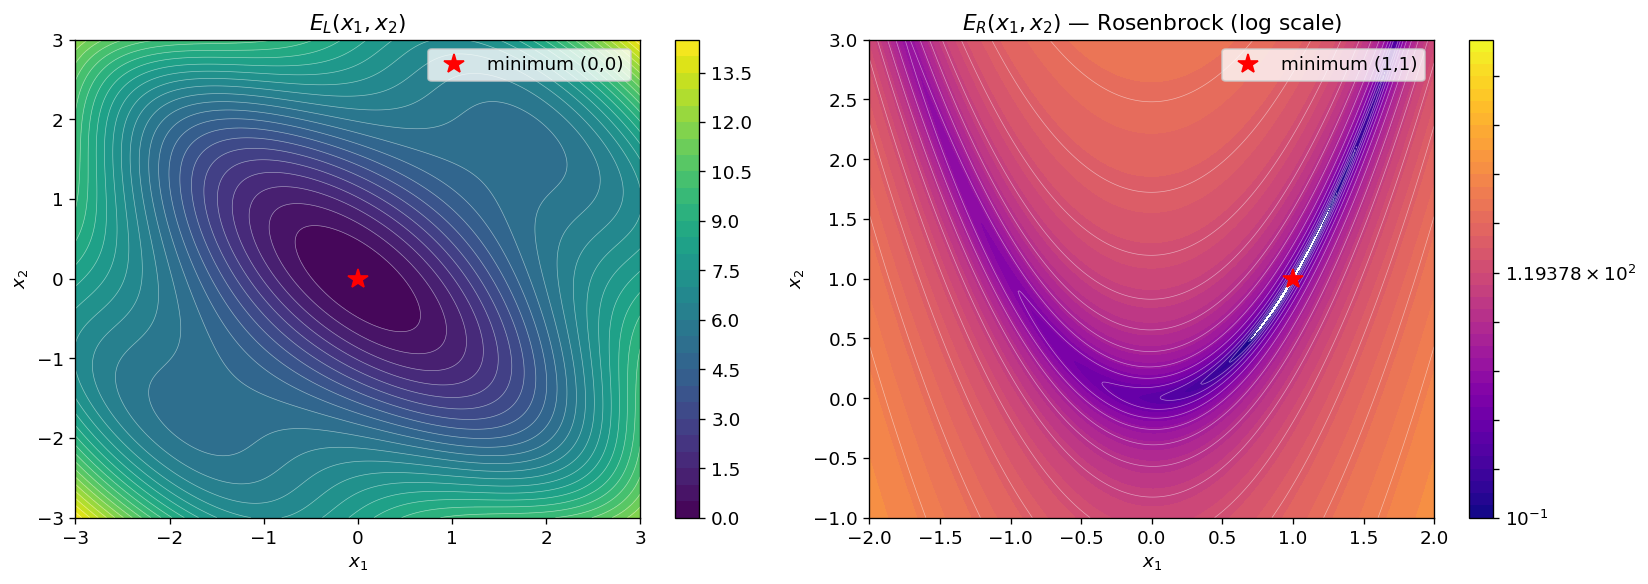

In [65]:
# B)

def make_grid(xlim, ylim, n=400):
    
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    X, Y = np.meshgrid(xs, ys)
    return X, Y

# EL Grid
XL, YL = make_grid((-3, 3), (-3, 3))
ZL = EL_fn(XL, YL)

# ER Grid
XR, YR = make_grid((-2, 2), (-1, 3))
ZR = ER_fn(XR, YR)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EL contour
ax = axes[0]
cp = ax.contourf(XL, YL, ZL, levels=30, cmap='viridis')
ax.contour(XL, YL, ZL, levels=30, colors='white', linewidths=0.4, alpha=0.5)
fig.colorbar(cp, ax=ax)
ax.set_title(r'$E_L(x_1,x_2)$', fontsize=13)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.plot(0, 0, 'r*', markersize=12, label='minimum (0,0)')
ax.legend()

# ER contour
ax = axes[1]
cp = ax.contourf(XR, YR, ZR, levels=np.logspace(-1, 5, 40), norm=LogNorm(), cmap='plasma')
ax.contour(XR, YR, ZR, levels=np.logspace(-1, 5, 20), norm=LogNorm(),
           colors='white', linewidths=0.4, alpha=0.5)
fig.colorbar(cp, ax=ax)
ax.set_title(r'$E_R(x_1,x_2)$ — Rosenbrock (log scale)', fontsize=13)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.plot(1, 1, 'r*', markersize=12, label='minimum (1,1)')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# C)

def newton_method(grad_fn, hess_fn, x0, eps=1e-4, max_iter=1000, max_step=0.5):
    x = np.array(x0, dtype=float)
    path = [x.copy()]

    for _ in range(max_iter):
        g = grad_fn(x)
        H = hess_fn(x)
        step = np.linalg.solve(H, g)


        # step damping to avoid divergence far from minimum
        step_norm = np.linalg.norm(step)
        if step_norm > max_step:
            step = step * (max_step / step_norm)

        x_new = x - step
        path.append(x_new.copy())

        if np.linalg.norm(x_new - x) < eps:
            return path, True
        x = x_new

    return path, False

newton_method() defined.


In [67]:
# D)

np.random.seed(42)


# EL: avoid exact zero which is already the minimum
starts_L = [
    np.array([ 1.5,  1.0]),
    np.array([-1.0,  2.0]),
    np.array([-2.0, -1.5]),
    np.array([ 0.5, -2.0]),
]

# ER: Rosenbrock. Start near but not at (1,1)
starts_R = [np.array([-1.5,  2.0]),
            np.array([ 0.5, -0.5]),
            np.array([-0.5,  1.5]),
            np.array([ 1.5,  0.5])]

print("Starting points for EL:", [s.tolist() for s in starts_L])
print("Starting points for ER:", [s.tolist() for s in starts_R])

Starting points for EL: [[1.5, 1.0], [-1.0, 2.0], [-2.0, -1.5], [0.5, -2.0]]
Starting points for ER: [[-1.5, 2.0], [0.5, -0.5], [-0.5, 1.5], [1.5, 0.5]]


In [68]:
results_L = []
print("Results for EL (minimum at (0,0)):")
for i, x0 in enumerate(starts_L):
    path, conv = newton_method(grad_EL, hess_EL, x0, eps=1e-4)
    results_L.append(path)
    xf = path[-1]
    print(f"  Start {i+1}: {np.round(x0,4)} → {np.round(xf,6)}  "
          f"({'converged' if conv else 'NOT converged'}, {len(path)-1} steps)")

Results for EL (minimum at (0,0)):
  Start 1: [1.5 1. ] → [1.630661 1.630661]  (NOT converged, 1000 steps)
  Start 2: [-1.  2.] → [-0. -0.]  (converged, 7 steps)
  Start 3: [-2.  -1.5] → [-1.580315 -1.580315]  (NOT converged, 1000 steps)
  Start 4: [ 0.5 -2. ] → [-1.628793 -1.628793]  (NOT converged, 1000 steps)


In [69]:
results_R = []
print("Results for ER (minimum at (1,1)):")
for i, x0 in enumerate(starts_R):
    path, conv = newton_method(grad_ER, hess_ER, x0, eps=1e-4)
    results_R.append(path)
    xf = path[-1]
    print(f"  Start {i+1}: {np.round(x0,4)} → {np.round(xf,6)}  "
          f"({'converged' if conv else 'NOT converged'}, {len(path)-1} steps)")

Results for ER (minimum at (1,1)):
  Start 1: [-1.5  2. ] → [1. 1.]  (converged, 17 steps)
  Start 2: [ 0.5 -0.5] → [1. 1.]  (converged, 8 steps)
  Start 3: [-0.5  1.5] → [1. 1.]  (converged, 13 steps)
  Start 4: [1.5 0.5] → [1. 1.]  (converged, 12 steps)


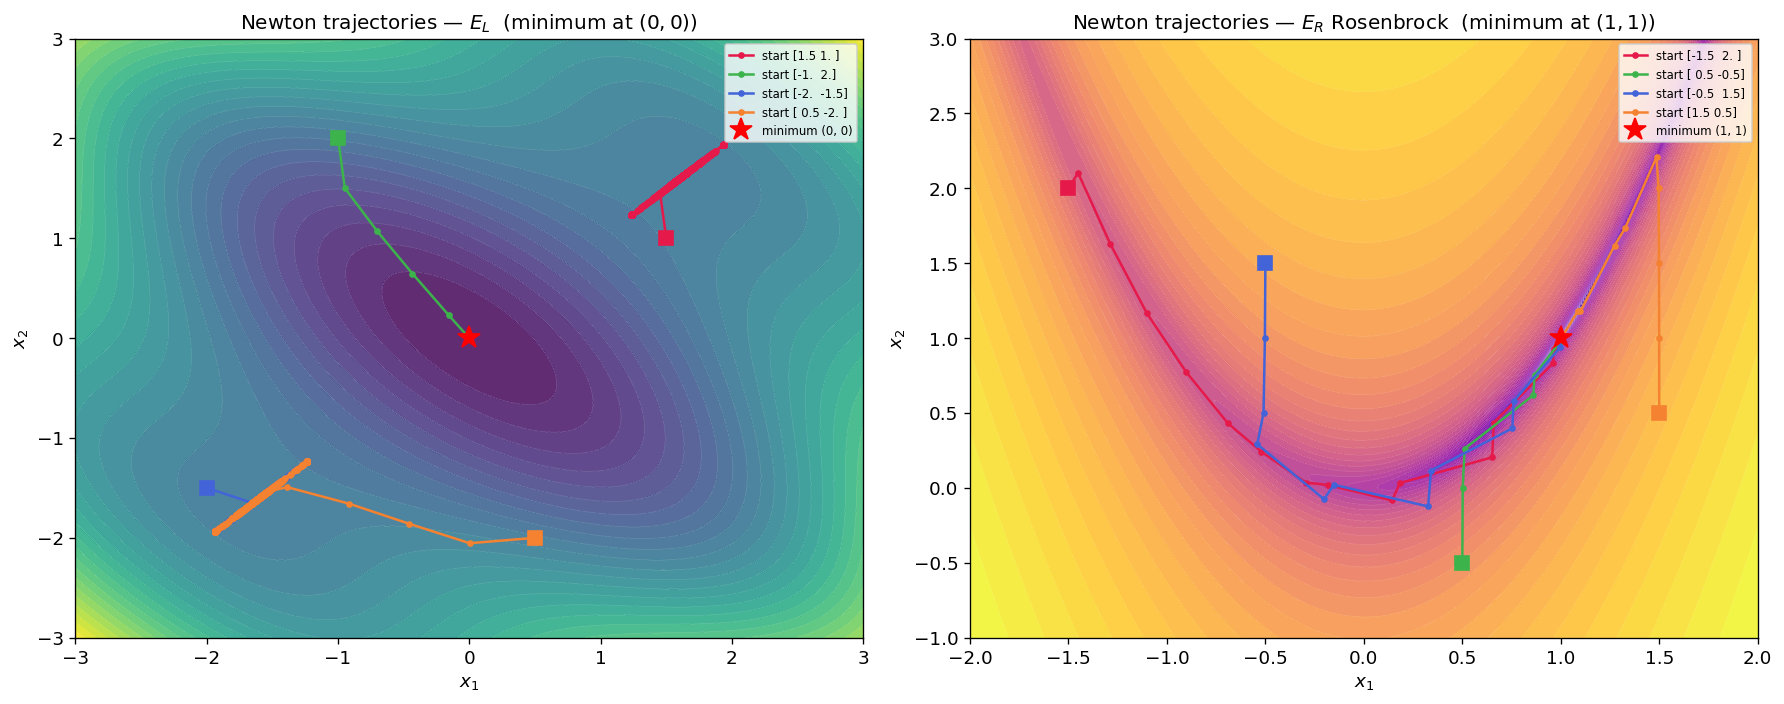

In [70]:
COLORS = ['#e6194b', '#3cb44b', '#4363d8', '#f58231']

def plot_trajectories(ax, paths, starts, minimum, title, X, Y, Z,
                      log_scale=False):
    if log_scale:
        levels = np.logspace(np.log10(max(Z.min(), 1e-2)), np.log10(Z.max()), 40)
        ax.contourf(X, Y, Z, levels=levels, norm=LogNorm(), cmap='plasma', alpha=0.85)
        ax.contour(X, Y, Z, levels=levels, norm=LogNorm(),
                   colors='white', linewidths=0.3, alpha=0.4)
    else:
        ax.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.85)
        ax.contour(X, Y, Z, levels=30, colors='white', linewidths=0.3, alpha=0.4)

    for path, x0, col in zip(paths, starts, COLORS):
        pts = np.array(path)
        ax.plot(pts[:, 0], pts[:, 1], '-o', color=col,
                markersize=3, linewidth=1.5, label=f'start {np.round(x0,2)}')
        ax.plot(x0[0], x0[1], 's', color=col, markersize=8)  # start marker

    ax.plot(*minimum, 'r*', markersize=14, zorder=5, label=f'minimum {minimum}')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    ax.legend(fontsize=7, loc='upper right')


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_trajectories(axes[0], results_L, starts_L, (0, 0),
                  r'Newton trajectories — $E_L$  (minimum at $(0,0)$)',
                  XL, YL, ZL, log_scale=False)

plot_trajectories(axes[1], results_R, starts_R, (1, 1),
                  r'Newton trajectories — $E_R$ Rosenbrock  (minimum at $(1,1)$)',
                  XR, YR, ZR, log_scale=True)

plt.tight_layout()
plt.show()